# 6.2.- Bag of Words (BoW) y TF–IDF

En este notebook aprenderás a transformar texto en **vectores numéricos** para poder usar modelos de *Machine Learning*.

Los modelos no pueden trabajar con palabras directamente, sino con **números** que representen su contenido.  
Aquí veremos dos métodos clásicos de vectorización:

1. **Bag of Words (BoW)** – Cuenta cuántas veces aparece cada palabra.  
2. **TF–IDF (Term Frequency – Inverse Document Frequency)** – Ajusta la importancia de cada palabra según su frecuencia.

Finalmente, entrenaremos un **clasificador supervisado** para predecir si una frase tiene un sentimiento positivo o negativo.

In [16]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Configuración general
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

## Conjunto de datos de ejemplo

Usaremos un pequeño conjunto de frases con **opiniones positivas y negativas**.  
En proyectos reales, se emplean datasets grandes como IMDb, Amazon Reviews o Tweets, pero aquí trabajaremos con un corpus pequeño para visualizar los resultados fácilmente.

In [28]:
# Pequeño dataset manual
data = {
    "texto": [
        "Me encantó la película, fue increíble",
        "Odio esta serie, es aburrida y larga",
        "La comida estaba deliciosa y bien servida",
        "El servicio fue pésimo, no volveré nunca",
        "Excelente atención y muy buena experiencia",
        "El producto llegó roto y tarde",
        "Estoy muy feliz con la compra",
        "No me gustó, esperaba mucho más",
        "Todo salió perfecto, muy recomendado",
        "Fue una pérdida de tiempo y dinero"
    ],
    "sentimiento": [
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0  # 1 = positivo, 0 = negativo
    ]
}

df = pd.DataFrame(data)

def limpiar_texto(texto):
    texto = texto.lower()  # minúsculas
    texto = re.sub(r"[^a-záéíóúüñ ]", "", texto)  # quitar signos y caracteres especiales
    texto = re.sub(r"\s+", " ", texto).strip()  # espacios múltiples
    return texto

# Aplicar limpieza a todas las frases
df["texto"] = df["texto"].apply(limpiar_texto)

df

,texto,sentimiento
0,me encantó la película fue increíble,1
1,odio esta serie es aburrida y larga,0
2,la comida estaba deliciosa y bien servida,1
3,el servicio fue pésimo no volveré nunca,0
4,excelente atención y muy buena experiencia,1
5,el producto llegó roto y tarde,0
6,estoy muy feliz con la compra,1
7,no me gustó esperaba mucho más,0
8,todo salió perfecto muy recomendado,1
9,fue una pérdida de tiempo y dinero,0


## Bag of Words (BoW)

El modelo **Bag of Words** crea un vector con las frecuencias de cada palabra en el texto.  
No considera el orden ni el contexto, solo **qué palabras aparecen** y **cuántas veces**.

Pasos:
1. Crear el vectorizador `CountVectorizer`
2. Ajustarlo al corpus (`fit_transform`)
3. Obtener las palabras del vocabulario

In [29]:
# Crear vectorizador BoW
vectorizer_bow = CountVectorizer()

# Transformar el texto a matriz numérica
X_bow = vectorizer_bow.fit_transform(df["texto"])

# Mostrar vocabulario y matriz
print("Vocabulario:\n", vectorizer_bow.get_feature_names_out())
print("\nMatriz BoW:\n", X_bow.toarray())

Vocabulario:
 ['aburrida' 'atención' 'bien' 'buena' 'comida' 'compra' 'con' 'de'
 'deliciosa' 'dinero' 'el' 'encantó' 'es' 'esperaba' 'esta' 'estaba'
 'estoy' 'excelente' 'experiencia' 'feliz' 'fue' 'gustó' 'increíble' 'la'
 'larga' 'llegó' 'me' 'mucho' 'muy' 'más' 'no' 'nunca' 'odio' 'película'
 'perfecto' 'producto' 'pérdida' 'pésimo' 'recomendado' 'roto' 'salió'
 'serie' 'servicio' 'servida' 'tarde' 'tiempo' 'todo' 'una' 'volveré']

Matriz BoW:
 [[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0
  0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
  0 1 0 0 0 0 1 0 0 0 0 0 1]
 [0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 

## Clasificación usando BoW

Entrenaremos un **Naive Bayes Multinomial**, un modelo muy usado en clasificación de texto.  
Dividiremos los datos en entrenamiento y prueba, y evaluaremos su rendimiento.

In [30]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(X_bow, df["sentimiento"], test_size=0.3, random_state=33)

# Entrenar modelo
clf_bow = MultinomialNB()
clf_bow.fit(X_train, y_train)

# Predicciones
y_pred_bow = clf_bow.predict(X_test)

# Evaluación
print("Accuracy BoW:", accuracy_score(y_test, y_pred_bow))
print("\nReporte de clasificación (BoW):\n")
print(classification_report(y_test, y_pred_bow))

Accuracy BoW: 1.0

Reporte de clasificación (BoW):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



## TF–IDF (Term Frequency – Inverse Document Frequency)

Mientras que BoW trata todas las palabras igual, **TF–IDF** penaliza las más comunes y resalta las más informativas.

- **TF (Term Frequency):** frecuencia de la palabra en el documento.  
- **IDF (Inverse Document Frequency):** mide cuán rara es esa palabra en el conjunto.

Esto produce representaciones más equilibradas para tareas de clasificación o búsqueda.

In [31]:
# Crear vectorizador TF–IDF
vectorizer_tfidf = TfidfVectorizer()

# Transformar el texto
X_tfidf = vectorizer_tfidf.fit_transform(df["texto"])

# Mostrar vocabulario y matriz TF–IDF
print("Vocabulario TF–IDF:\n", vectorizer_tfidf.get_feature_names_out())
print("\nMatriz TF–IDF (valores redondeados):\n", np.round(X_tfidf.toarray(), 2))

Vocabulario TF–IDF:
 ['aburrida' 'atención' 'bien' 'buena' 'comida' 'compra' 'con' 'de'
 'deliciosa' 'dinero' 'el' 'encantó' 'es' 'esperaba' 'esta' 'estaba'
 'estoy' 'excelente' 'experiencia' 'feliz' 'fue' 'gustó' 'increíble' 'la'
 'larga' 'llegó' 'me' 'mucho' 'muy' 'más' 'no' 'nunca' 'odio' 'película'
 'perfecto' 'producto' 'pérdida' 'pésimo' 'recomendado' 'roto' 'salió'
 'serie' 'servicio' 'servida' 'tarde' 'tiempo' 'todo' 'una' 'volveré']

Matriz TF–IDF (valores redondeados):
 [[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.46 0.   0.
  0.   0.   0.   0.   0.   0.   0.34 0.   0.46 0.34 0.   0.   0.39 0.
  0.   0.   0.   0.   0.   0.46 0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.  ]
 [0.41 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.41 0.
  0.41 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.41 0.   0.   0.
  0.   0.   0.   0.   0.41 0.   0.   0.   0.   0.   0.   0.   0.   0.41
  0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.42 

## Clasificación usando TF–IDF

Repetimos el mismo procedimiento anterior, pero usando la representación TF–IDF.  
Esto suele mejorar la precisión en comparación con BoW.

In [32]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df["sentimiento"], test_size=0.3, random_state=42)

# Entrenar modelo
clf_tfidf = MultinomialNB()
clf_tfidf.fit(X_train, y_train)

# Predicciones
y_pred_tfidf = clf_tfidf.predict(X_test)

# Evaluación
print("Accuracy TF–IDF:", accuracy_score(y_test, y_pred_tfidf))
print("\nReporte de clasificación (TF–IDF):\n")
print(classification_report(y_test, y_pred_tfidf, zero_division=0))

Accuracy TF–IDF: 0.3333333333333333

Reporte de clasificación (TF–IDF):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



## Comparación BoW vs TF–IDF

A continuación, compararemos visualmente la precisión de ambos enfoques.

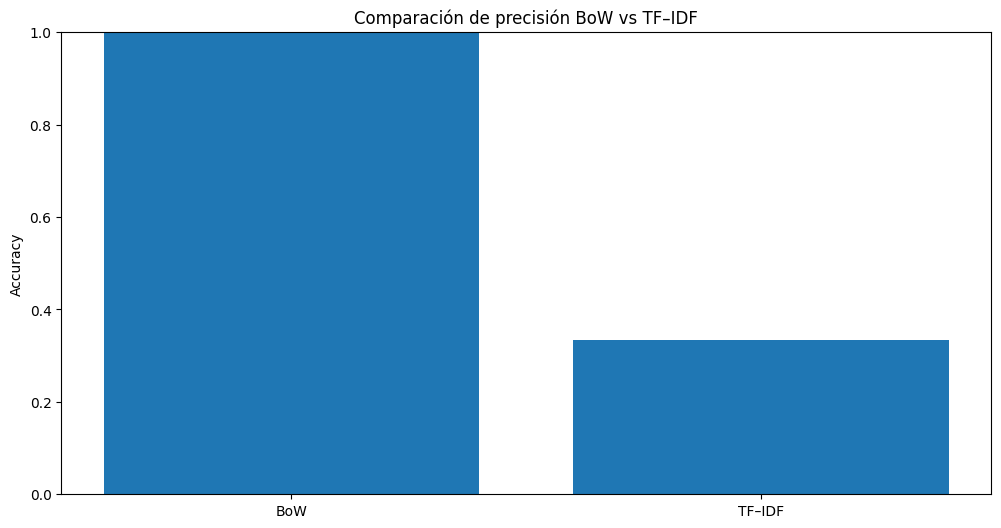

In [33]:
scores = {
    "BoW": accuracy_score(y_test, y_pred_bow),
    "TF–IDF": accuracy_score(y_test, y_pred_tfidf)
}

plt.bar(scores.keys(), scores.values())
plt.title("Comparación de precisión BoW vs TF–IDF")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## Ejercicio Final

1. Añade al dataset más frases positivas y negativas (mínimo 5 de cada tipo).
2. Realiza una tokenización y eliminación de *Stopwords*
3. Reentrena el modelo con BoW y TF–IDF.  
4. Observa cómo cambian las métricas.  
5. Reflexiona: ¿qué método captura mejor el significado de los textos?